# Stationary heat conduction in a 2D truss
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/truss/thermal_static.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/truss/thermal_static.ipynb)

The truss of `elasticity_2D`, conducting heat instead of carrying load. Each bar
conducts along its own axis, so the heat routes through the members.

In [1]:
import torch

from torchfem import TrussHeat
from torchfem.materials import IsotropicConductivity1D

torch.set_default_dtype(torch.float64)

## Model setup

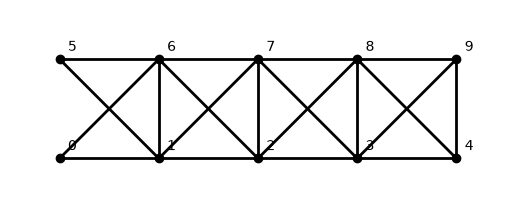

In [2]:
# Create material
material = IsotropicConductivity1D(50.0)

n1 = torch.linspace(0.0, 4.0, 5)
n2 = torch.linspace(0.0, 1.0, 2)
n1, n2 = torch.stack(torch.meshgrid(n1, n2, indexing="xy"))
nodes = torch.stack([n1.ravel(), n2.ravel()], dim=1)

elements = torch.tensor(
    [
        [0, 1],
        [1, 2],
        [2, 3],
        [3, 4],
        [5, 6],
        [6, 7],
        [7, 8],
        [8, 9],
        [1, 5],
        [0, 6],
        [2, 6],
        [1, 7],
        [3, 7],
        [2, 8],
        [4, 8],
        [3, 9],
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
    ]
)

# Create truss
truss = TrussHeat(nodes, elements, material)

# Set boundary conditions: cold at the left end, hot at the right
truss.constraints[[0, 5]] = True
truss.constraints[[4, 9]] = True
truss.temperatures[[4, 9]] = 100.0

# Visualize truss
truss.plot(node_labels=True)

## Solve

In [3]:
temp, rfl, q, temp_grad, _ = truss.solve()

## Visualize the axial heat flux

A bar between two nodes of equal temperature carries none, so the vertical members
drop out and the heat travels along the chords and diagonals.

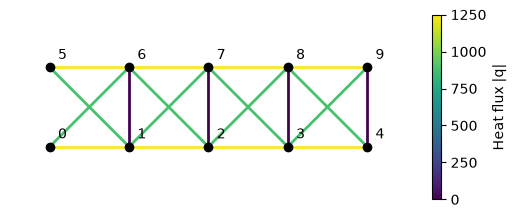

In [4]:
truss.plot(element_property={"Heat flux |q|": q.abs()})